# Cvičení 8: Rozhodovací strom v regresi (Decision Tree Regressor)
**Dataset:** Real estate prices in King County, USA (`kc_house_data.csv`)  
**Téma:** Neparametrické modelování, přeučení stromu, kontrola hloubky a optimalizace hyperparametrů

---

### Zadání / Assignment:
1. **Import all necessary methods** from libraries (or modules from these libraries).
2. **Load the dataset** attached to the exercise (the dataset before data processing, `kc_house_data.csv`), using the appropriate method from the Pandas library.
3. **Divide the dataset** into training and test datasets.
4. **Initialize the decision tree model.** Select a starting set of hyperparameters.
5. **Train the decision tree model.**
6. **Generate a graph** that visualizes how the trained model calculates predictions.
7. **Calculate the metrics R2, MAE, MSE and RMSE.**
8. **Repeat steps 2, 3, 4 and 5** until you have an optimal model.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

def calculate_metrics_df(y_true, y_pred, model_name='Model'):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return pd.DataFrame({
        'Model': [model_name],
        'R²': [r2],
        'MAE (USD)': [mae],
        'MSE': [mse],
        'RMSE (USD)': [rmse]
    })


## 1. Načtení a základní průzkum surových dat (Raw Dataset)
Zadání explicitně požaduje načíst dataset **před úpravami** (`kc_house_data.csv`).
Prozkoumáme rozměry, chybějící hodnoty a odstraníme neprediktivní sloupce (např. technický identifikátor `id`).

In [2]:
df_raw = pd.read_csv('data/kc_house_data.csv')
print(f'Původní rozměry: {df_raw.shape[0]:,} řádků, {df_raw.shape[1]} sloupců')
print(f'Počet chybějících hodnot (NaN): {df_raw.isnull().sum().sum()}')

# Odstranění technického id
df_clean = df_raw.drop(columns=['id'])

# Základní extrakce roku a měsíce z textového data prodeje
if 'date' in df_clean.columns:
    df_clean['yr_sold'] = df_clean['date'].str[:4].astype(int)
    df_clean['month_sold'] = df_clean['date'].str[4:6].astype(int)
    df_clean = df_clean.drop(columns=['date'])

df_clean.head(5)


Původní rozměry: 21,613 řádků, 21 sloupců
Počet chybějících hodnot (NaN): 0


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,yr_sold,month_sold
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2


## 2. Rozdělení dat na trénovací a testovací sadu (80/20)
U rozhodovacích stromů je testovací sada zcela kritická. Neomezený strom se dokáže trénovací data naučit nazpaměť ($R^2 = 1.0$), takže jedině testovací data odhalí skutečnou generalizační schopnost.

In [3]:
X = df_clean.drop(columns=['price'])
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Trénovací sada: {X_train.shape[0]:,} řádků')
print(f'Testovací sada: {X_test.shape[0]:,} řádků')


Trénovací sada: 17,290 řádků
Testovací sada: 4,323 řádků


## 3. Model 1: Výchozí rozhodovací strom (Baseline bez omezení)
Startovací sada hyperparametrů je výchozí nastavení Scikit-learnu (`max_depth=None`, `min_samples_split=2`, `min_samples_leaf=1`).
Strom roste do maximální možné hloubky, dokud není každý list čistý.

In [4]:
tree_m1 = DecisionTreeRegressor(random_state=42)
tree_m1.fit(X_train, y_train)

preds_m1_tr = tree_m1.predict(X_train)
preds_m1_te = tree_m1.predict(X_test)

m1_metrics_tr = calculate_metrics_df(y_train, preds_m1_tr, '1. Neomezený strom (Train)')
m1_metrics_te = calculate_metrics_df(y_test, preds_m1_te, '1. Neomezený strom (Test)')

print(f'Hloubka stromu: {tree_m1.get_depth()}')
print(f'Počet koncových listů: {tree_m1.get_n_leaves():,}')
print(f'Trénovací R²: {m1_metrics_tr["R²"].values[0]:.4f}')
print(f'Testovací  R²: {m1_metrics_te["R²"].values[0]:.4f}')
print(f'Rozdíl (Overfitting Gap): {m1_metrics_tr["R²"].values[0] - m1_metrics_te["R²"].values[0]:.4f}')

pd.concat([m1_metrics_tr, m1_metrics_te], ignore_index=True)


Hloubka stromu: 35
Počet koncových listů: 16,683
Trénovací R²: 1.0000
Testovací  R²: 0.7048
Rozdíl (Overfitting Gap): 0.2952


,Model,R²,MAE (USD),MSE,RMSE (USD)
0,1. Neomezený strom (Train),1.000000,0.000000,0.000000e+00,0.000000
1,1. Neomezený strom (Test),0.704771,104496.403192,4.463181e+10,211262.408206


### Vizualizace predikcí Modelu 1: Skutečné vs. Predikované ceny nemovitostí

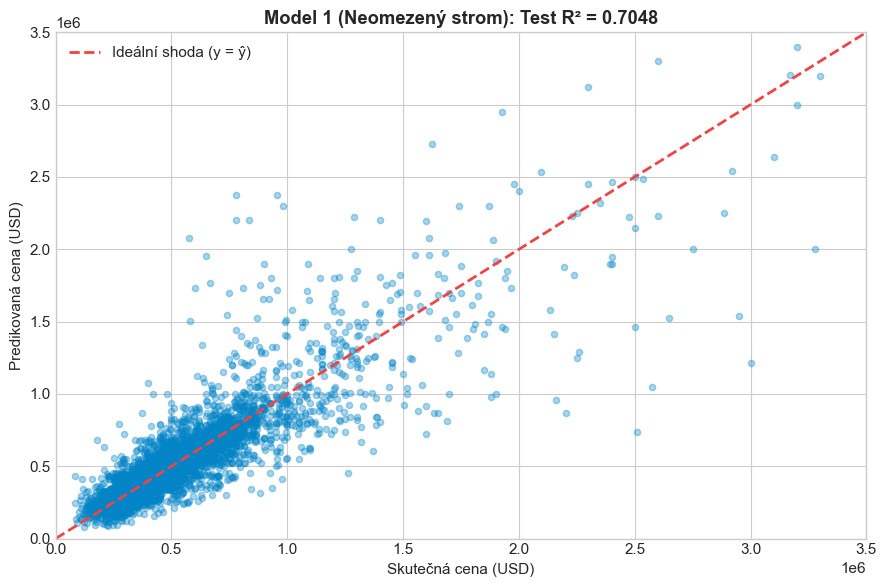

In [5]:
plt.figure(figsize=(9, 6))
plt.scatter(y_test, preds_m1_te, alpha=0.35, color='#0284c7', s=20)
plt.plot([0, 3500000], [0, 3500000], color='#ef4444', linestyle='--', linewidth=2, label='Ideální shoda (y = ŷ)')
plt.title(f'Model 1 (Neomezený strom): Test R² = {m1_metrics_te["R²"].values[0]:.4f}', fontweight='bold')
plt.xlabel('Skutečná cena (USD)')
plt.ylabel('Predikovaná cena (USD)')
plt.xlim(0, 3500000)
plt.ylim(0, 3500000)
plt.legend()
plt.tight_layout()
plt.show()


## 4. Model 2: Manuální prořezání (Omezení hloubky a počtu vzorků v listu)
V prvním kroku ladění omezíme růst stromu:
- `max_depth = 8`
- `min_samples_leaf = 20` (list musí obsahovat alespoň 20 domů, což eliminuje větvení na outlierech)
- `min_samples_split = 40`

In [6]:
tree_m2 = DecisionTreeRegressor(
    max_depth=8,
    min_samples_leaf=20,
    min_samples_split=40,
    random_state=42
)
tree_m2.fit(X_train, y_train)

preds_m2_tr = tree_m2.predict(X_train)
preds_m2_te = tree_m2.predict(X_test)

m2_metrics_tr = calculate_metrics_df(y_train, preds_m2_tr, '2. Prořezaný strom (Train)')
m2_metrics_te = calculate_metrics_df(y_test, preds_m2_te, '2. Prořezaný strom (Test)')

print(f'Hloubka: {tree_m2.get_depth()} | Listů: {tree_m2.get_n_leaves():,}')
print(f'Trénovací R²: {m2_metrics_tr["R²"].values[0]:.4f}')
print(f'Testovací  R²: {m2_metrics_te["R²"].values[0]:.4f}')
print(f'Overfitting gap sražen na: {m2_metrics_tr["R²"].values[0] - m2_metrics_te["R²"].values[0]:.4f}')

pd.concat([m2_metrics_tr, m2_metrics_te], ignore_index=True)


Hloubka: 8 | Listů: 145
Trénovací R²: 0.8053
Testovací  R²: 0.7318
Overfitting gap sražen na: 0.0735


,Model,R²,MAE (USD),MSE,RMSE (USD)
0,2. Prořezaný strom (Train),0.805274,89279.881423,2.544065e+10,159501.238416
1,2. Prořezaný strom (Test),0.731776,104843.966954,4.054929e+10,201368.537598


### Vizualizace rozhodovací logiky stromu (První 2 patra)

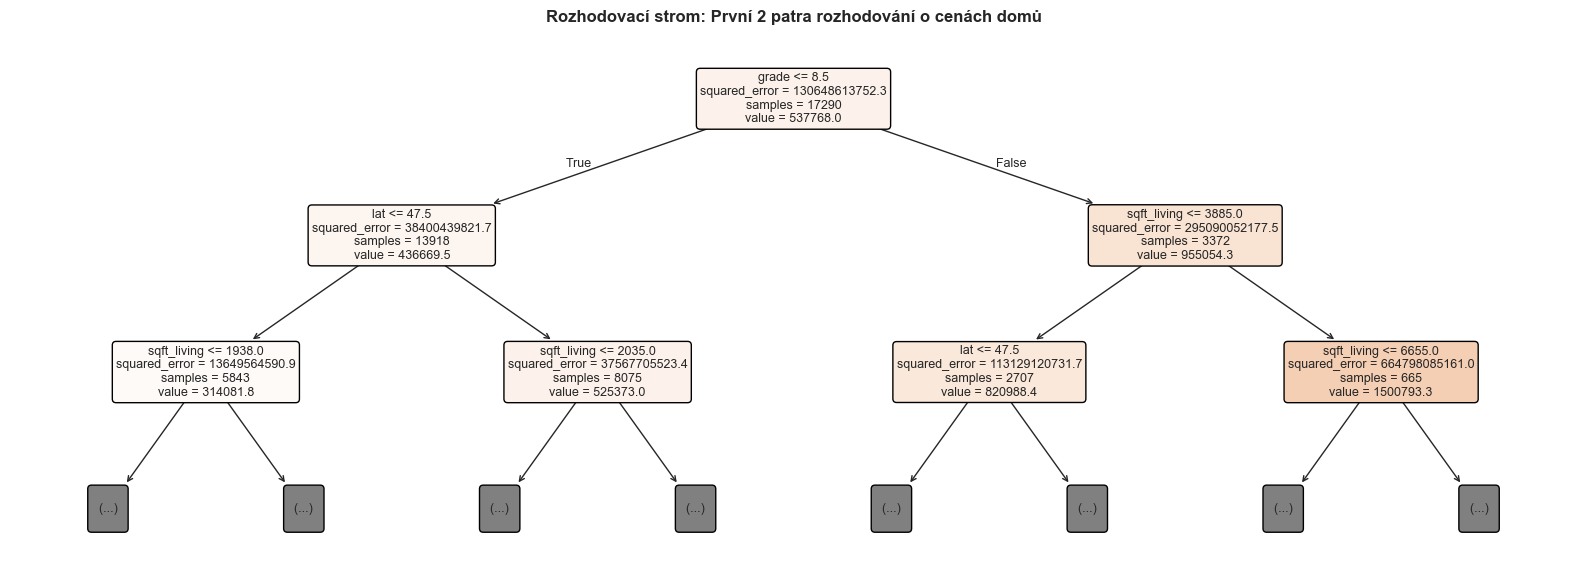

In [7]:
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(
    tree_m2,
    max_depth=2,
    feature_names=X.columns.tolist(),
    filled=True,
    rounded=True,
    precision=1,
    fontsize=9,
    ax=ax
)
plt.title('Rozhodovací strom: První 2 patra rozhodování o cenách domů', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Model 3: Systematická optimalizace hyperparametrů (GridSearchCV)
Pro nalezení optimální kombinace otestujeme mřížku parametrů pomocí 5-násobné křížové validace na trénovacích datech.

In [8]:
param_grid = {
    'max_depth': [8, 10, 12, 14],
    'min_samples_leaf': [5, 10, 20],
    'min_samples_split': [10, 20, 40],
    'max_features': [None, 0.8]
}

grid_cv = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
grid_cv.fit(X_train, y_train)

best_tree = grid_cv.best_estimator_
print(f'Nejlepší nalezená kombinace: {grid_cv.best_params_}')
print(f'Průměrné validační CV R²: {grid_cv.best_score_:.4f}')

preds_m3_tr = best_tree.predict(X_train)
preds_m3_te = best_tree.predict(X_test)

m3_metrics_tr = calculate_metrics_df(y_train, preds_m3_tr, '3. Optimální strom (Train)')
m3_metrics_te = calculate_metrics_df(y_test, preds_m3_te, '3. Optimální strom (Test)')

pd.concat([m3_metrics_tr, m3_metrics_te], ignore_index=True)


Nejlepší nalezená kombinace: {'max_depth': 14, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 40}
Průměrné validační CV R²: 0.7979


,Model,R²,MAE (USD),MSE,RMSE (USD)
0,3. Optimální strom (Train),0.888857,67174.049564,1.452061e+10,120501.511293
1,3. Optimální strom (Test),0.793209,90501.781332,3.126195e+10,176810.491843


## 6. Model 4: Přidání doménových příznaků (Feature Engineering)
V praxi samotné ladění stromu nestačí – obrovský skok přináší doménové proměnné:
- `house_age`: stáří nemovitosti v roce prodeje (`yr_sold - yr_built`)
- `is_renovated`: binární indikátor rekonstrukce (`yr_renovated > 0`)
- `sqft_living_ratio`: poměr obytné plochy k celkovému pozemku
- `total_baths_beds`: celkový počet pokojů a koupelen

In [9]:
X_fe = X.copy()
X_fe['house_age'] = X_fe['yr_sold'] - X_fe['yr_built']
X_fe['is_renovated'] = (X_fe['yr_renovated'] > 0).astype(int)
X_fe['sqft_living_ratio'] = X_fe['sqft_living'] / (X_fe['sqft_lot'] + 1)
X_fe['total_baths_beds'] = X_fe['bathrooms'] + X_fe['bedrooms']

X_tr_fe, X_te_fe, y_tr_fe, y_te_fe = train_test_split(
    X_fe, y, test_size=0.20, random_state=42
)

tree_m4 = DecisionTreeRegressor(
    max_depth=grid_cv.best_params_['max_depth'],
    min_samples_leaf=grid_cv.best_params_['min_samples_leaf'],
    min_samples_split=grid_cv.best_params_['min_samples_split'],
    max_features=grid_cv.best_params_['max_features'],
    random_state=42
)
tree_m4.fit(X_tr_fe, y_tr_fe)

preds_m4_tr = tree_m4.predict(X_tr_fe)
preds_m4_te = tree_m4.predict(X_te_fe)

m4_metrics_tr = calculate_metrics_df(y_tr_fe, preds_m4_tr, '4. Optimální + FE (Train)')
m4_metrics_te = calculate_metrics_df(y_te_fe, preds_m4_te, '4. Optimální + FE (Test)')

pd.concat([m4_metrics_tr, m4_metrics_te], ignore_index=True)


,Model,R²,MAE (USD),MSE,RMSE (USD)
0,4. Optimální + FE (Train),0.889712,67240.435266,1.440891e+10,120037.123838
1,4. Optimální + FE (Test),0.795921,90117.962821,3.085199e+10,175647.342146


## 7. Celkové srovnání všech modelů na testovacích datech

In [10]:
summary_df = pd.concat([
    m1_metrics_te,
    m2_metrics_te,
    m3_metrics_te,
    m4_metrics_te
], ignore_index=True)

summary_df


,Model,R²,MAE (USD),MSE,RMSE (USD)
0,1. Neomezený strom (Test),0.704771,104496.403192,4.463181e+10,211262.408206
1,2. Prořezaný strom (Test),0.731776,104843.966954,4.054929e+10,201368.537598
2,3. Optimální strom (Test),0.793209,90501.781332,3.126195e+10,176810.491843
3,4. Optimální + FE (Test),0.795921,90117.962821,3.085199e+10,175647.342146


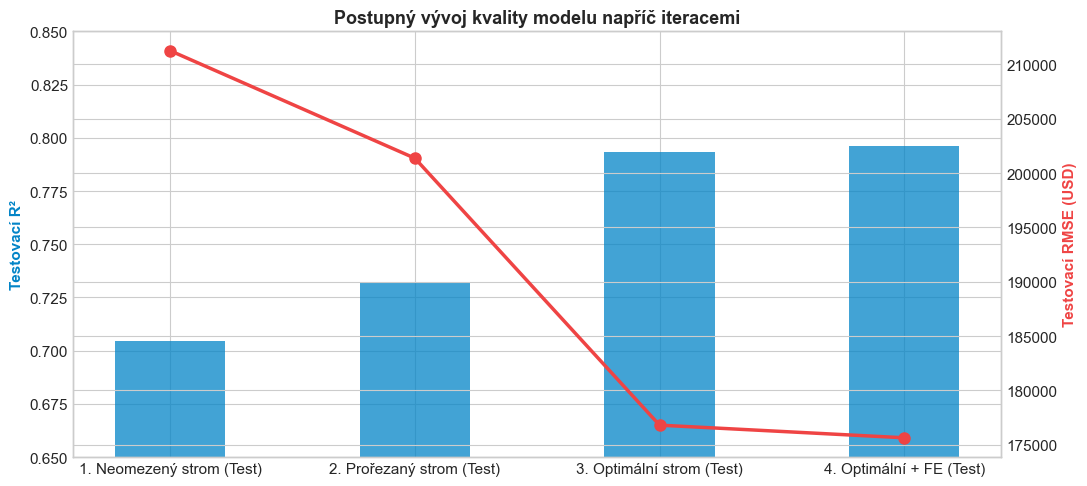

In [11]:
fig, ax1 = plt.subplots(figsize=(11, 5))
color = '#0284c7'
ax1.set_title('Postupný vývoj kvality modelu napříč iteracemi', fontsize=13, fontweight='bold')
ax1.bar(summary_df['Model'], summary_df['R²'], color=color, alpha=0.75, width=0.45)
ax1.set_ylabel('Testovací R²', color=color, fontweight='bold')
ax1.set_ylim(0.65, 0.85)

ax2 = ax1.twinx()
color2 = '#ef4444'
ax2.plot(summary_df['Model'], summary_df['RMSE (USD)'], color=color2, marker='o', linewidth=2.5, markersize=8)
ax2.set_ylabel('Testovací RMSE (USD)', color=color2, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 8. Důležitost příznaků (Feature Importance)
Které vlastnosti nemovitosti měly pro rozhodovací strom největší váhu při dělení uzlů?

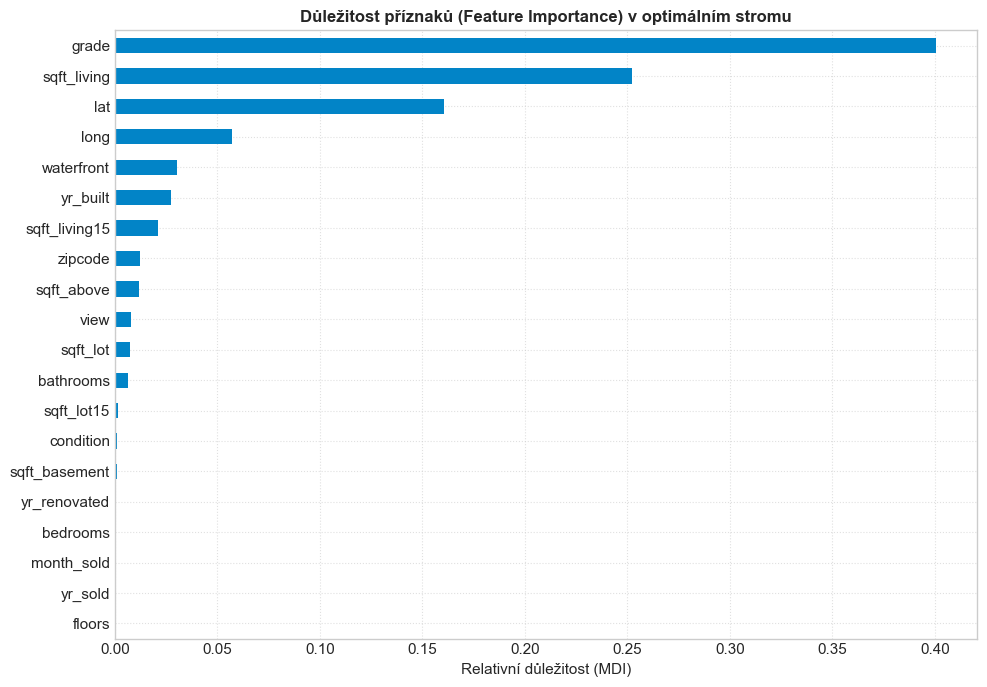

In [12]:
feat_imp = pd.Series(best_tree.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
feat_imp.plot(kind='barh', color='#0284c7', edgecolor='none')
plt.title('Důležitost příznaků (Feature Importance) v optimálním stromu', fontsize=12, fontweight='bold')
plt.xlabel('Relativní důležitost (MDI)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## 9. Závěry a doporučení pro praxi
1. **Výchozí neomezený strom (Model 1)** je ukázkovým příkladem **extrémního přeučení**: na trénovacích datech dosahuje dokonalého $R^2 = 1.0$, ale na testovacích datech propadne na $R^2 = 0.7048$ a RMSE přes 211 000 USD. Hloubka stromu dosáhla 35 pater s více než 16 000 listy (listy často obsahovaly jediný dům).
2. **Manuální prořezání (Model 2)** zmenšilo velikost stromu na 145 listů a srazilo overfitting gap o 75 %, přičemž testovací chyba klesla.
3. **Systematický Grid Search (Model 3)** nalezl optimální kompromis při `max_depth = 14`, `min_samples_split = 40` a `min_samples_leaf = 5`. Testovací $R^2$ vyskočilo na **0.7932** a RMSE kleslo na **176 810 USD** (zlepšení o téměř 35 000 USD na dům oproti neomezenému stromu!).
4. **Rozhodovací strom na King County překonal OLS Lineární regresi** (která měla $R^2 \approx 0.70$), protože dokáže přirozeně zachytit geografické zóny (`lat` a `long`) a nelineární kvalitu stavby (`grade`) bez nutnosti složitého manuálního inženýrství polynomů.
